In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [25]:
df = pd.read_csv('cardekho_dataset.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [26]:
df = df.drop(columns='Unnamed: 0')

In [27]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [28]:
df.shape

(15411, 13)

In [29]:
df = df.drop(columns='car_name')

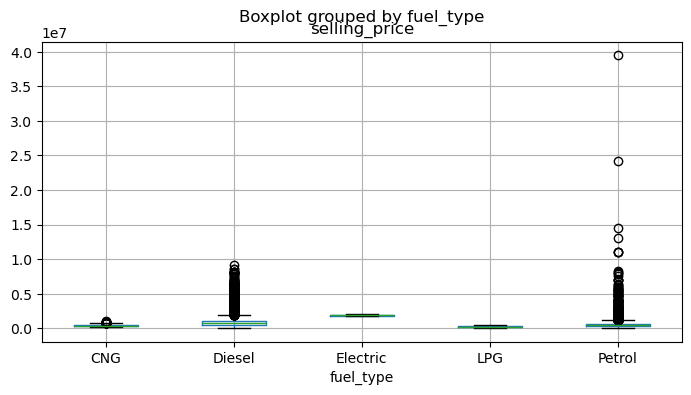

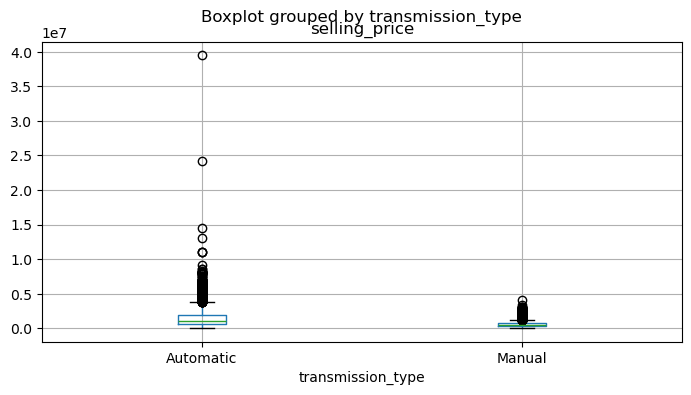

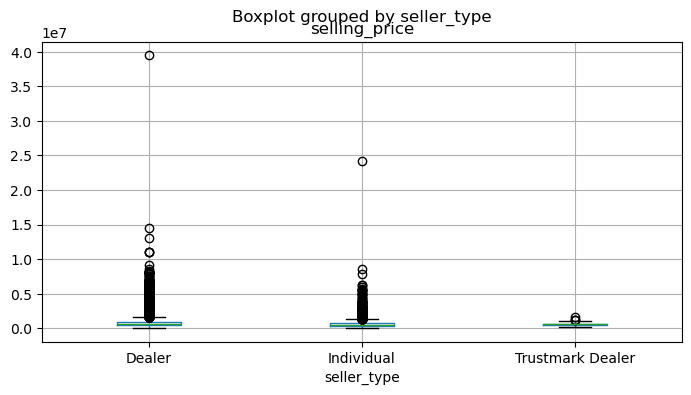

In [30]:
for col in ['fuel_type', 'transmission_type', 'seller_type']:
    df.boxplot(column='selling_price', by=col, figsize=(8,4))
    plt.show()

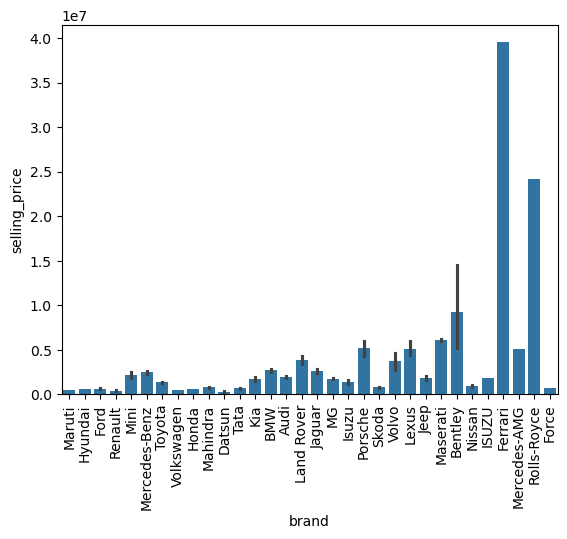

In [31]:
sns.barplot(data=df, x='brand', y = 'selling_price')
plt.xticks(rotation=90)
plt.show()

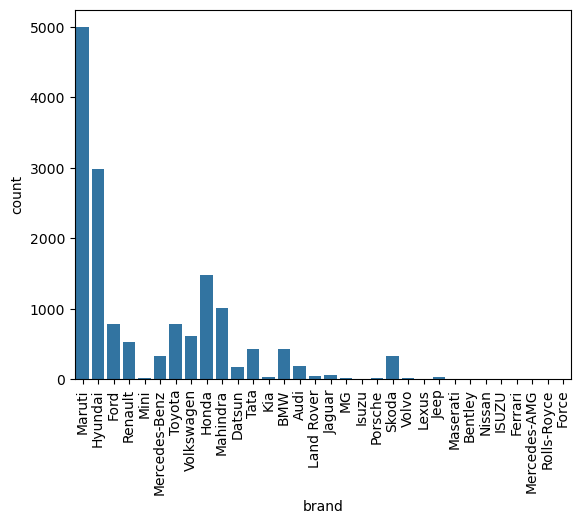

In [32]:
sns.countplot(data=df, x='brand')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='vehicle_age', ylabel='selling_price'>

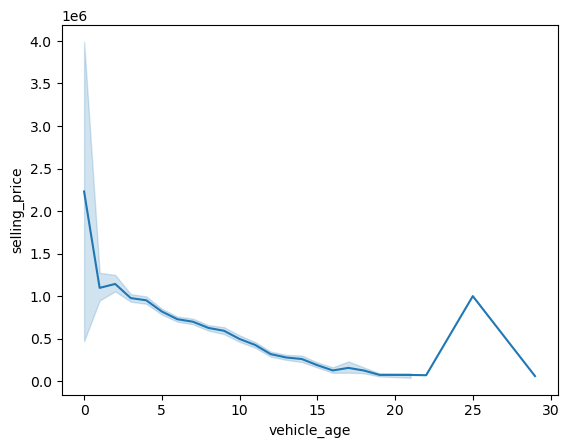

In [33]:
sns.lineplot(data=df, x='vehicle_age', y='selling_price')

Text(0, 0.5, 'Median Selling Price')

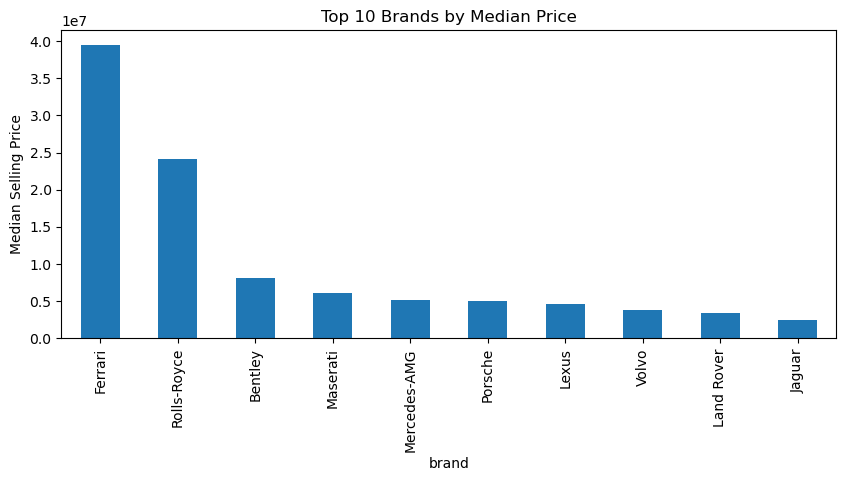

In [34]:
df.groupby('brand')['selling_price'].median().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10, 4))
plt.title('Top 10 Brands by Median Price')
plt.ylabel('Median Selling Price')

In [35]:
df['selling_price'] = np.log(df['selling_price'])

In [36]:
df['selling_price']

0        11.695247
1        13.217674
2        12.278393
3        12.328290
4        13.253392
           ...    
15406    12.429216
15407    13.737549
15408    12.959844
15409    14.018451
15410    13.997832
Name: selling_price, Length: 15411, dtype: float64

In [37]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [38]:
X.columns

Index(['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats'],
      dtype='object')

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [40]:
brand_frq = X_train['brand'].value_counts()
X_train['brand_encoded'] = X_train['brand'].map(brand_frq)
X_test['brand_encoded'] = X_test['brand'].map(brand_frq)

model_freq = X_train['model'].value_counts()
X_train['model_encoded'] = X_train['model'].map(model_freq)
X_test['model_encoded'] = X_test['model'].map(model_freq)

In [41]:
X_train.drop(columns=['brand', 'model'], inplace=True)
X_test.drop(columns=['brand', 'model'], inplace=True)

In [42]:
log = ['km_driven', 'engine', 'max_power']
num = ['vehicle_age', 'mileage', 'brand_encoded', 'model_encoded']
cate = ['seller_type', 'fuel_type', 'transmission_type', 'seats']

In [43]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

log_trans = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('log_num', log_trans, log),
    ('num', StandardScaler(), num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cate)   
])

model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBRegressor(
        n_estimators = 300,
        learning_rate = 0.1,
        max_depth = 6,
        random_state = 42,
        n_jobs = -1,
    ))
])

model.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log_num', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_xgb = model.predict(X_test)

print('Model Metrics (log):')
print('R2 Score:', r2_score(y_test, y_pred_xgb))
print('MAE:', mean_absolute_error(y_test, y_pred_xgb))
print('MSE:', mean_squared_error(y_test, y_pred_xgb))

Model Metrics (log):
R2 Score: 0.9414837039504899
MAE: 0.12439291295802775
MSE: 0.029237452191967977


In [45]:
y_pred_actual = np.exp(y_pred_xgb)
y_test_actual = np.exp(y_test)

comparison = pd.DataFrame({
    'Actual Price': y_test_actual.values,
    'Predicted Price': y_pred_actual}).head(10)

comparison = comparison.applymap(lambda x: f"{int(x):,}")
print('\nSample Pred:')
print(comparison)


Sample Pred:
  Actual Price Predicted Price
0      190,000         231,079
1      599,999         641,168
2      665,000         631,418
3    1,570,000       1,331,766
4      159,999         166,032
5      675,000         410,615
6      464,999         423,309
7      260,000         291,118
8      299,999         351,479
9      849,999       1,024,361


C:\Users\shyam\AppData\Local\Temp\ipykernel_29160\241255455.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  comparison = comparison.applymap(lambda x: f"{int(x):,}")


In [46]:
import joblib

joblib.dump(model, 'car_model.joblib')
print('Model saved!')

Model saved!
